In [ ]:
!pip install xee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.1 MB/s eta 0:00:00


In [ ]:
import ee
import xee
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import geemap

In [ ]:
ee.Authenticate()
ee.Initialize(
    project = 'ee-abirnahraf'
)

/usr/local/lib/python3.12/dist-packages/ee/data.py:335: UserWarning: Your project has exceeded the compute quota of its noncommercial tier and is currently in restricted mode.
  warnings.warn(


In [ ]:
# 10km² box ≈ 0.045° × 0.045° in central Dhaka (Motijheel area)
aoi = ee.Geometry.Rectangle([
    90.390,   # lon_min
    23.720,   # lat_min
    90.435,   # lon_max  (lon_min + 0.045°)
    23.765    # lat_max  (lat_min + 0.045°)
])

# Verify on map
Map = geemap.Map()
Map.addLayer(aoi, {'color': 'red'}, '10km² AOI')
Map.centerObject(aoi, zoom=13)
Map

Map(center=[23.742500332720624, 90.41250000000059], controls=(WidgetControl(options=['position', 'transparent_…

In [ ]:
sentinel = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2020-01-01', '2020-03-01')
    .filterBounds(aoi)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .select(['B4', 'B3', 'B2'])   # R, G, B only
    .first()                       # single image
)

print("Image found:", sentinel.getInfo()['id'])

Image found: COPERNICUS/S2_SR_HARMONIZED/20200117T043121_20200117T043313_T45QZG


In [ ]:
bounds = aoi.bounds().getInfo()['coordinates'][0]

lons = [float(pt[0]) for pt in bounds]
lats = [float(pt[1]) for pt in bounds]

lon_min, lon_max = min(lons), max(lons)
lat_min, lat_max = min(lats), max(lats)

print(f"lon : {lon_min} → {lon_max}")
print(f"lat : {lat_min} → {lat_max}")

lon : 90.39 → 90.435
lat : 23.71999999999997 → 23.765001629377053


In [ ]:
scale_original = 0.0001

width_orig  = int((lon_max - lon_min) / scale_original)
height_orig = int((lat_max - lat_min) / scale_original)
print(f"Original — {height_orig} × {width_orig} px")   # ~450×450

ds_original = xr.open_dataset(
    ee.ImageCollection(sentinel),
    engine        = 'ee',
    crs           = 'EPSG:4326',
    crs_transform = (scale_original, 0, lon_min, 0, -scale_original, lat_max),
    shape_2d      = (height_orig, width_orig),
    io_chunks     = {'x': 64, 'y': 64}
)

print(ds_original)

Original — 450 × 450 px
<xarray.Dataset> Size: 2MB
Dimensions:  (time: 1, y: 450, x: 450)
Coordinates:
  * time     (time) datetime64[ns] 8B 2020-01-17T04:41:52.625000
  * y        (y) float64 4kB 23.76 23.76 23.76 23.76 ... 23.72 23.72 23.72 23.72
  * x        (x) float64 4kB 90.39 90.39 90.39 90.39 ... 90.43 90.43 90.43 90.43
Data variables:
    B4       (time, y, x) float32 810kB ...
    B3       (time, y, x) float32 810kB ...
    B2       (time, y, x) float32 810kB ...


In [ ]:
scale_coarse = 0.001

width_crs  = int((lon_max - lon_min) / scale_coarse)
height_crs = int((lat_max - lat_min) / scale_coarse)
print(f"Coarse — {height_crs} × {width_crs} px")   # ~45×45

ds_coarse = xr.open_dataset(
    ee.ImageCollection(sentinel),
    engine        = 'ee',
    crs           = 'EPSG:4326',
    crs_transform = (scale_coarse, 0, lon_min, 0, -scale_coarse, lat_max),
    shape_2d      = (height_crs, width_crs),
)

print(ds_coarse)

Coarse — 45 × 45 px
<xarray.Dataset> Size: 25kB
Dimensions:  (time: 1, y: 45, x: 45)
Coordinates:
  * time     (time) datetime64[ns] 8B 2020-01-17T04:41:52.625000
  * y        (y) float64 360B 23.76 23.76 23.76 23.76 ... 23.72 23.72 23.72
  * x        (x) float64 360B 90.39 90.39 90.39 90.39 ... 90.43 90.43 90.43
Data variables:
    B4       (time, y, x) float32 8kB ...
    B3       (time, y, x) float32 8kB ...
    B2       (time, y, x) float32 8kB ...


In [ ]:
def to_rgb(ds):
    r = ds['B4'].isel(time=0).values.astype(float)
    g = ds['B3'].isel(time=0).values.astype(float)
    b = ds['B2'].isel(time=0).values.astype(float)
    rgb = np.stack([r, g, b], axis=-1)
    rgb = np.clip(rgb / 3000.0, 0, 1)   # normalize 0-1
    return rgb

rgb_orig   = to_rgb(ds_original)
rgb_coarse = to_rgb(ds_coarse)

print("Original shape :", rgb_orig.shape)
print("Coarse   shape :", rgb_coarse.shape)

Original shape : (450, 450, 3)
Coarse   shape : (45, 45, 3)


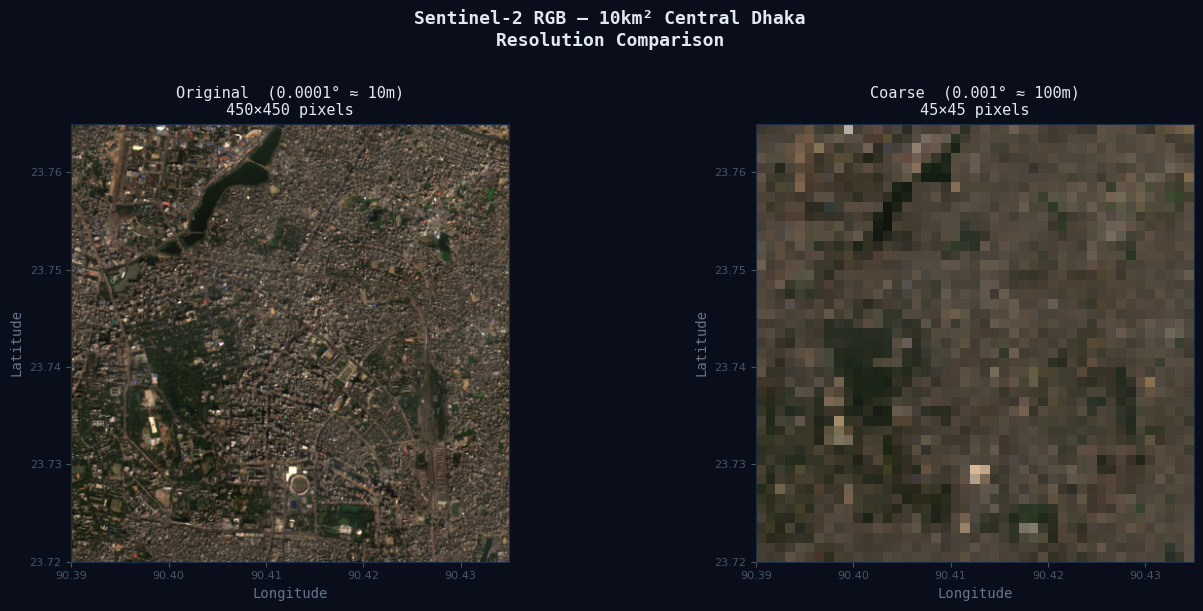

Done.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#0a0e1a')

# Original
axes[0].imshow(rgb_orig, extent=[lon_min, lon_max, lat_min, lat_max])
axes[0].set_title(f'Original  (0.0001° ≈ 10m)\n{height_orig}×{width_orig} pixels',
                  color='#e2e8f0', fontsize=11, fontfamily='monospace')
axes[0].set_xlabel('Longitude', color='#64748b', fontfamily='monospace')
axes[0].set_ylabel('Latitude',  color='#64748b', fontfamily='monospace')
axes[0].tick_params(colors='#475569', labelsize=8)
axes[0].set_facecolor('#0a0e1a')
for sp in axes[0].spines.values(): sp.set_edgecolor('#1e2d45')

# Coarse
axes[1].imshow(rgb_coarse, extent=[lon_min, lon_max, lat_min, lat_max])
axes[1].set_title(f'Coarse  (0.001° ≈ 100m)\n{height_crs}×{width_crs} pixels',
                  color='#e2e8f0', fontsize=11, fontfamily='monospace')
axes[1].set_xlabel('Longitude', color='#64748b', fontfamily='monospace')
axes[1].set_ylabel('Latitude',  color='#64748b', fontfamily='monospace')
axes[1].tick_params(colors='#475569', labelsize=8)
axes[1].set_facecolor('#0a0e1a')
for sp in axes[1].spines.values(): sp.set_edgecolor('#1e2d45')

fig.suptitle('Sentinel-2 RGB — 10km² Central Dhaka\nResolution Comparison',
             color='#e2e8f0', fontsize=13, fontweight='bold',
             fontfamily='monospace', y=1.01)

plt.tight_layout()
plt.savefig('dhaka_10km_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print("Done.")

In [ ]:
# Left panel — original 10m
left = geemap.ee_tile_layer(
    sentinel,
    {
        'bands': ['B4', 'B3', 'B2'],
        'min': 0,
        'max': 3000,
        'gamma': 1.4
    },
    'Original 10m'
)

# Right panel — resampled to 100m
right = geemap.ee_tile_layer(
    sentinel.resample('bilinear').reproject(
        crs='EPSG:4326',
        scale=100          # 100m = coarse
    ),
    {
        'bands': ['B4', 'B3', 'B2'],
        'min': 0,
        'max': 3000,
        'gamma': 1.4
    },
    'Coarse 100m'
)

# Split map
Map = geemap.Map()
Map.centerObject(aoi, zoom=14)
Map.split_map(left, right)
Map

Map(center=[23.742500332722248, 90.41250000000059], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [ ]:
import os
os.makedirs('downloads', exist_ok=True)

In [ ]:
# Original 10m
geemap.ee_export_image(
    sentinel,
    filename    = 'downloads/sentinel_10m.tif',
    scale       = 10,
    region      = aoi,
    crs         = 'EPSG:4326',
    file_per_band = False
)
print("Original 10m downloaded.")

Generating URL ...
Please wait ...
Data downloaded to /content/downloads/sentinel_10m.tif
Original 10m downloaded.


In [ ]:
# Coarse 100m
geemap.ee_export_image(
    sentinel.resample('bilinear').reproject(
        crs  = 'EPSG:4326',
        scale = 100
    ),
    filename    = 'downloads/sentinel_100m.tif',
    scale       = 100,
    region      = aoi,
    crs         = 'EPSG:4326',
    file_per_band = False
)
print("Coarse 100m downloaded.")

Generating URL ...
Please wait ...
Data downloaded to /content/downloads/sentinel_100m.tif
Coarse 100m downloaded.


In [ ]:
# Verify both files downloaded
import os
for f in os.listdir('downloads'):
    size = os.path.getsize(f'downloads/{f}') / 1024
    print(f"{f}  —  {size:.1f} KB")

sentinel_10m.tif  —  1045.0 KB
sentinel_100m.tif  —  13.5 KB
